## Sportmonks Germany 201 — 02: Gegenpressing proxies

**Hypothesis (proxy):** higher defensive disruption and higher pressure (when available) support a *gegenpressing* narrative; a **PPDA-style** proxy (opponent passes ÷ Germany defensive actions) gives a coarse “how hard we press without the ball” measure.

**Limitation:** Sportmonks match statistics are not event coordinates; this is **evidence for discussion**, not optical tracking.

Prerequisite: run `sportmonks_germany_201_01_fixture_corpus.ipynb` to create `fixtures_germany_201.csv` and `germany_201_meta.json`.

PPDA (passes per defensive action)

In [10]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import load_dotenv

ROOT = Path.cwd()
if (ROOT / "sportmonks").is_dir():
    SPORTMONKS_DIR = ROOT / "sportmonks"
    sys.path.insert(0, str(SPORTMONKS_DIR))
else:
    SPORTMONKS_DIR = ROOT
    sys.path.insert(0, str(ROOT))

import sportmonks_germany_api as smg

In [11]:
load_dotenv(".env")

API_TOKEN = os.getenv("API_TOKEN")

In [12]:
import json

meta_path = SPORTMONKS_DIR / "germany_201_meta.json"
if not meta_path.exists():
    raise FileNotFoundError("Run notebook 01 first (missing germany_201_meta.json)")
GERMANY_TEAM_ID = int(json.loads(meta_path.read_text(encoding="utf-8"))["germany_team_id"])

fx_path = SPORTMONKS_DIR / "fixtures_germany_201.csv"
fixtures = pd.read_csv(fx_path, parse_dates=["starting_at"])
fixtures.head()

,id,sport_id,league_id,season_id,stage_id,group_id,aggregate_id,round_id,state_id,venue_id,name,starting_at,result_info,leg,details,length,placeholder,has_odds,has_premium_odds,starting_at_timestamp
0,19032613,1,1326,22842,77468274,250003.0,NaN,327513.0,5,53,Germany vs Scotland,2024-06-14 19:00:00,Germany won after full-time.,1/1,Match 1,90,False,True,True,1718391600
1,19032614,1,1326,22842,77468274,250003.0,NaN,327514.0,5,1945,Germany vs Hungary,2024-06-19 16:00:00,Germany won after full-time.,1/1,Match 14,90,False,True,True,1718812800
2,19032615,1,1326,22842,77468274,250003.0,NaN,327515.0,5,339832,Switzerland vs Germany,2024-06-23 19:00:00,Game ended in draw.,1/1,Match 25,90,False,True,True,1719169200
3,19032605,1,1326,22842,77468273,NaN,NaN,NaN,5,2166,Germany vs Denmark,2024-06-29 19:00:00,Germany won after full-time.,1/1,Match 37,90,False,True,True,1719687600
4,19032601,1,1326,22842,77468272,NaN,NaN,NaN,7,1945,Spain vs Germany,2024-07-05 16:00:00,Spain won after extra-time.,1/1,Match 45,90,False,True,True,1720195200


### Fetch statistics + timeline (plan-dependent)
The **`pressure`** include requires a higher SportMonks subscription (API error **5002** if missing). This notebook uses `statistics.type` + `timeline` only; `pressure_mean` will be empty unless you add `pressure` to `INCLUDE` on a plan that includes it.

Set `MAX_FIXTURES` to a small number for a quick dry run.

In [13]:
MAX_FIXTURES = None  # e.g. 5 for testing

# Omit "pressure" unless your plan includes it (403 + code 5002 otherwise).
INCLUDE = "statistics.type;timeline"


def stat_pick(sd: dict, *keys: str) -> float:
    for k in keys:
        if k in sd and sd[k] == sd[k]:
            return float(sd[k])
    return float("nan")


rows = []
ids = fixtures["id"].tolist()
if MAX_FIXTURES is not None:
    ids = ids[: int(MAX_FIXTURES)]

for fid in ids:
    data = smg.get_fixture(API_TOKEN, int(fid), INCLUDE)
    stats_df = smg.normalize_fixture_statistics(data)
    g = smg.stats_dict_for_team(stats_df, GERMANY_TEAM_ID)
    oid = smg.opponent_participant_id(stats_df, GERMANY_TEAM_ID)
    o = smg.stats_dict_for_team(stats_df, oid) if oid is not None else {}

    tackles = stat_pick(g, "tackles", "TACKLES")
    interceptions = stat_pick(g, "interceptions", "INTERCEPTIONS")
    clearances = stat_pick(g, "clearances", "CLEARANCES")
    blocks = stat_pick(
        g,
        "blocked-scoring-attempt",
        "blocked_scoring_attempt",
        "shots-blocked",
    )
    fouls = stat_pick(g, "fouls", "FOULS", "team-fouls")
    ball_rec = stat_pick(
        g, "ball-recoveries", "ball_recoveries", "BALL_RECOVERIES"
    )

    def_act = np.nansum(
        [tackles, interceptions, clearances, blocks, ball_rec]
    )
    opp_passes = stat_pick(o, "passes", "PASSES", "successful-passes", "successful_passes")
    ppda_proxy = opp_passes / def_act if def_act and def_act == def_act and opp_passes == opp_passes else float("nan")

    press = smg.mean_pressure_for_participant(data, GERMANY_TEAM_ID)

    tl = data.get("timeline") or []
    tl_df = pd.json_normalize(tl)
    early_events = 0
    if not tl_df.empty and "minute" in tl_df.columns:
        early_events = int(tl_df[tl_df["minute"] <= 15].shape[0])

    rows.append(
        {
            "fixture_id": int(fid),
            "starting_at": fixtures.loc[fixtures["id"] == fid, "starting_at"].iloc[0],
            "league_id": int(fixtures.loc[fixtures["id"] == fid, "league_id"].iloc[0]),
            "ger_tackles": tackles,
            "ger_interceptions": interceptions,
            "ger_clearances": clearances,
            "ger_blocks": blocks,
            "ger_fouls": fouls,
            "ger_ball_recoveries": ball_rec,
            "defensive_actions_sum": def_act,
            "opp_passes": opp_passes,
            "ppda_proxy": ppda_proxy,
            "pressure_mean": press,
            "timeline_events_leq15": early_events,
        }
    )

press_df = pd.DataFrame(rows)
press_df.head()

,fixture_id,starting_at,league_id,ger_tackles,ger_interceptions,ger_clearances,ger_blocks,ger_fouls,ger_ball_recoveries,defensive_actions_sum,opp_passes,ppda_proxy,pressure_mean,timeline_events_leq15
0,19032613,2024-06-14 19:00:00,1326,10.0,2.0,NaN,5.0,15.0,NaN,17.0,251.0,14.764706,None,3
1,19032614,2024-06-19 16:00:00,1326,17.0,6.0,NaN,7.0,12.0,NaN,30.0,308.0,10.266667,None,10
2,19032615,2024-06-23 19:00:00,1326,17.0,7.0,NaN,5.0,12.0,NaN,29.0,331.0,11.413793,None,6
3,19032605,2024-06-29 19:00:00,1326,7.0,8.0,NaN,1.0,7.0,NaN,16.0,444.0,27.750000,None,10
4,19032601,2024-07-05 16:00:00,1326,23.0,9.0,NaN,7.0,22.0,NaN,39.0,576.0,14.769231,None,4


In [14]:
out = SPORTMONKS_DIR / "germany_pressing_features.csv"
press_df.to_csv(out, index=False)

### By competition: PPDA proxy & defensive actions
Lower PPDA (fewer opponent passes per defensive action) is often read as more aggressive pressing in analytics blogs — validate against video when presenting.

In [15]:
%%capture --no-display

league_labels = {1326: "Euro 2024", 1538: "Nations League 25", 720: "WCQ Europe"}
press_df["competition"] = press_df["league_id"].map(league_labels).fillna(
    press_df["league_id"].astype(str)
)

g = press_df.groupby("competition", dropna=False).agg(
    matches=("fixture_id", "count"),
    ppda_proxy_median=("ppda_proxy", "median"),
    defensive_actions_median=("defensive_actions_sum", "median"),
    pressure_median=("pressure_mean", "median"),
)
g

,matches,ppda_proxy_median,defensive_actions_median,pressure_median
competition,,,,
Euro 2024,5,14.764706,29.0,NaN
Nations League 25,10,12.960714,29.0,NaN
WCQ Europe,6,13.316886,19.5,NaN


In [16]:
press_df

,fixture_id,starting_at,league_id,ger_tackles,ger_interceptions,ger_clearances,ger_blocks,ger_fouls,ger_ball_recoveries,defensive_actions_sum,opp_passes,ppda_proxy,pressure_mean,timeline_events_leq15,competition
0,19032613,2024-06-14 19:00:00,1326,10.0,2.0,NaN,5.0,15.0,NaN,17.0,251.0,14.764706,None,3,Euro 2024
1,19032614,2024-06-19 16:00:00,1326,17.0,6.0,NaN,7.0,12.0,NaN,30.0,308.0,10.266667,None,10,Euro 2024
2,19032615,2024-06-23 19:00:00,1326,17.0,7.0,NaN,5.0,12.0,NaN,29.0,331.0,11.413793,None,6,Euro 2024
3,19032605,2024-06-29 19:00:00,1326,7.0,8.0,NaN,1.0,7.0,NaN,16.0,444.0,27.750000,None,10,Euro 2024
4,19032601,2024-07-05 16:00:00,1326,23.0,9.0,NaN,7.0,22.0,NaN,39.0,576.0,14.769231,None,4,Euro 2024
5,19085361,2024-09-07 18:45:00,1538,16.0,3.0,NaN,5.0,13.0,NaN,24.0,464.0,19.333333,None,4,Nations League 25
6,19085364,2024-09-10 18:45:00,1538,21.0,7.0,NaN,8.0,13.0,NaN,36.0,345.0,9.583333,None,5,Nations League 25
7,19085365,2024-10-11 18:45:00,1538,13.0,4.0,NaN,3.0,9.0,NaN,20.0,252.0,12.600000,None,5,Nations League 25
8,19085368,2024-10-14 18:45:00,1538,16.0,12.0,NaN,5.0,10.0,NaN,33.0,523.0,15.848485,None,4,Nations League 25
9,19085369,2024-11-16 19:45:00,1538,19.0,8.0,NaN,4.0,7.0,NaN,31.0,291.0,9.387097,None,1,Nations League 25


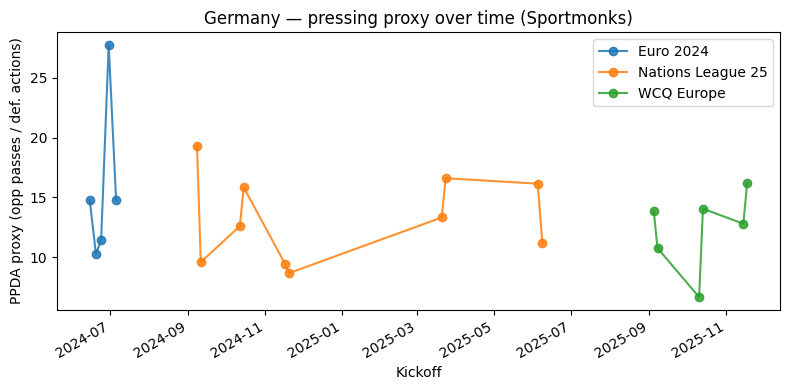

In [17]:
fig, ax = plt.subplots(figsize=(8, 4))
for comp, sub in press_df.groupby("competition"):
    sub = sub.sort_values("starting_at")
    ax.plot(sub["starting_at"], sub["ppda_proxy"], marker="o", linestyle="-", label=comp, alpha=0.85)
ax.set_ylabel("PPDA proxy (opp passes / def. actions)")
ax.set_xlabel("Kickoff")
ax.legend()
ax.set_title("Germany — pressing proxy over time (Sportmonks)")
fig.autofmt_xdate()
plt.tight_layout()